# Reto 4 - Clasificación de Flores parte 4
## Modelos: KNN y Gradient Boosting

En este notebook se entrenan y comparan dos modelos de clasificación sobre el dataset Iris:
- **K-Nearest Neighbors (KNN)** con pipeline de escalado y búsqueda de hiperparámetros.
- **Gradient Boosting Classifier** con búsqueda de hiperparámetros.

Se evalúan mediante accuracy en test, reportes de clasificación, matrices de confusión y validación cruzada.

## 1. Importar Librerías Necesarias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

## 2. Cargar y Explorar el Dataset Iris

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

# Convertir a DataFrame para inspección
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
print("Primeras filas del dataset:")
print(df.head())
print("\nClases:", target_names)

Primeras filas del dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Clases: ['setosa' 'versicolor' 'virginica']


## 3. Separar Datos en Entrenamiento y Prueba

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Modelo 1: KNN

### Definir Pipeline y Grilla de Hiperparámetros

Se utiliza un Pipeline con `StandardScaler` (importante para KNN) y `KNeighborsClassifier`. La búsqueda de hiperparámetros incluye distancia Manhattan (p=1) y Euclidiana (p=2).

In [ ]:
# Pipeline con escalado + KNN
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"], # en distance, los vecinos más cercanos tienen más peso
    "knn__metric": ["minkowski"],
    "knn__p": [1, 2]  # 1=Manhattan, 2=Euclidiana
}

# GridSearchCV
grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Mejores hiperparámetros KNN:", grid_knn.best_params_)
print("Mejor accuracy en validación cruzada:", grid_knn.best_score_)

Mejores hiperparámetros KNN: {'knn__metric': 'minkowski', 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}
Mejor accuracy en validación cruzada: 0.9666666666666668


![Mathematical model: Distance formulas](https://lh5.googleusercontent.com/proxy/9g6N-pZQrlRaH0BQ95ibLVlFQd6QZzEYxDOio9EaouihdSI0weTd3jzrOADtGNqDPvK0XSzb_Hl_lcAsL1K3_RRcyM1d)

> Asigna a una nueva muestra la clase más común entre sus K vecinos más cercanos según una medida de distancia

![Mathematical model: Standard scale](https://miro.medium.com/v2/resize:fit:740/1*Nlgc_wq2b-VfdawWX9MLWA.png)

> Hace que todas las variables estén en la misma escala para que ninguna tenga más peso que otra

### Evaluación en Test y Reporte de Clasificación - KNN

In [5]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("Accuracy en test KNN:", accuracy_score(y_test, y_pred_knn))
print("\nReporte de clasificación KNN:")
print(classification_report(y_test, y_pred_knn, target_names=target_names))

Accuracy en test KNN: 0.9333333333333333

Reporte de clasificación KNN:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



### Matriz de Confusión - KNN

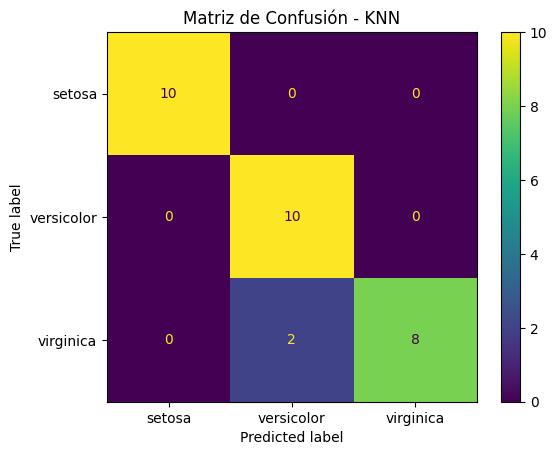

In [6]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=target_names)
disp_knn.plot()
plt.title("Matriz de Confusión - KNN")
plt.show()

### Validación Cruzada Completa - KNN

In [7]:
scores_knn = cross_val_score(best_knn, X, y, cv=5, scoring="accuracy")
print("Cross-validation accuracy KNN:", scores_knn)
print("Promedio CV KNN:", scores_knn.mean())

Cross-validation accuracy KNN: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Promedio CV KNN: 0.96


## 5. Modelo 2: Gradient Boosting

### Definir Modelo y Grilla de Hiperparámetros

Se entrena un `GradientBoostingClassifier` con búsqueda de hiperparámetros sobre número de estimadores, tasa de aprendizaje, profundidad máxima y subsample.

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "n_estimators": [50, 100, 150], # número de árboles en el ensemble
    "learning_rate": [0.01, 0.05, 0.1], # tasa de aprendizaje que controla cuánto cada árbol contribuye al modelo final
    "max_depth": [1, 2, 3],
    "subsample": [0.8, 1.0] # proporción de muestras utilizadas para entrenar cada árbol, ayuda a reducir el sobreajuste
}

# GridSearchCV
grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Mejores hiperparámetros Gradient Boosting:", grid_gb.best_params_)
print("Mejor accuracy en validación cruzada:", grid_gb.best_score_)

Mejores hiperparámetros Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Mejor accuracy en validación cruzada: 0.9666666666666668


![Mathematical model: Gradient Boosting formula](https://miro.medium.com/v2/resize:fit:1400/1*Q_kpJzwP_9Yb65LIAq4TlA.png)

> Método de ensemble que construye un modelo de manera secuencial, donde cada nuevo modelo intenta corregir los errores del anterior minimizando una función de pérdida mediante gradientes

### Evaluación en Test y Reporte de Clasificación - Gradient Boosting

In [9]:
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

print("Accuracy en test Gradient Boosting:", accuracy_score(y_test, y_pred_gb))
print("\nReporte de clasificación Gradient Boosting:")
print(classification_report(y_test, y_pred_gb, target_names=target_names))

Accuracy en test Gradient Boosting: 0.9666666666666667

Reporte de clasificación Gradient Boosting:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Matriz de Confusión - Gradient Boosting

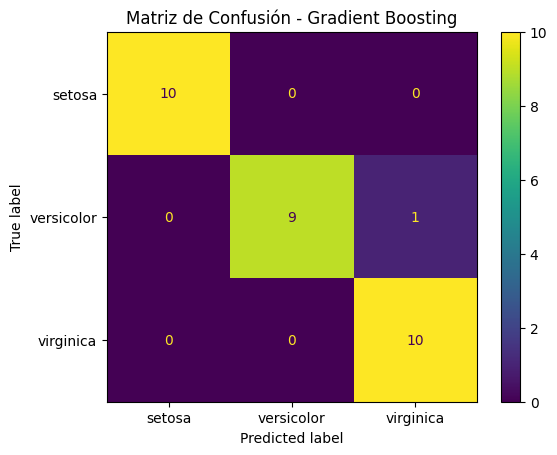

In [10]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=target_names)
disp_gb.plot()
plt.title("Matriz de Confusión - Gradient Boosting")
plt.show()

### Validación Cruzada Completa - Gradient Boosting

In [11]:
scores_gb = cross_val_score(best_gb, X, y, cv=5, scoring="accuracy")
print("Cross-validation accuracy Gradient Boosting:", scores_gb)
print("Promedio CV Gradient Boosting:", scores_gb.mean())

Cross-validation accuracy Gradient Boosting: [0.96666667 0.96666667 0.9        0.96666667 1.        ]
Promedio CV Gradient Boosting: 0.9600000000000002


## 6. Comparación Final de Modelos

Tabla comparativa con accuracy en test y accuracy promedio de validación cruzada para ambos modelos.

In [12]:
resultados = pd.DataFrame({
    "Modelo": ["KNN", "Gradient Boosting"],
    "Accuracy test": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Accuracy CV promedio": [
        scores_knn.mean(),
        scores_gb.mean()
    ]
})

print(resultados)

              Modelo  Accuracy test  Accuracy CV promedio
0                KNN       0.933333                  0.96
1  Gradient Boosting       0.966667                  0.96


### Gráfico Comparativo de Accuracy

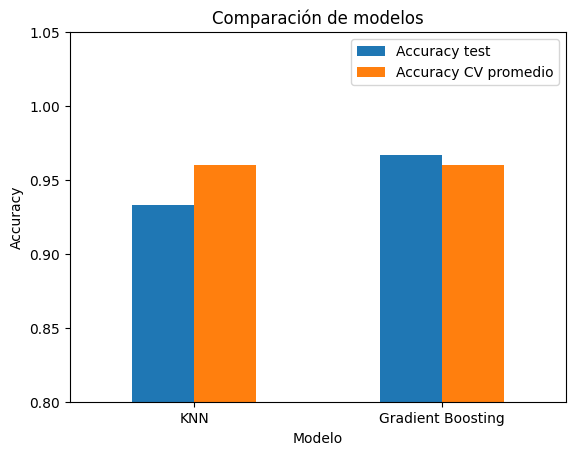

In [13]:
resultados.plot(x="Modelo", y=["Accuracy test", "Accuracy CV promedio"], kind="bar")
plt.ylim(0.8, 1.05)
plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

## 7. Conclusiones

- **Ambos modelos logran un alto rendimiento** en el dataset Iris, alcanzando valores de accuracy superiores al 90% tanto en test como en validación cruzada, lo cual es esperable dado que Iris es un dataset relativamente sencillo y bien separable.

- **KNN con escalado es competitivo:** El uso de `StandardScaler` dentro del pipeline fue fundamental para KNN, ya que este algoritmo es sensible a la escala de las variables. La búsqueda de hiperparámetros permitió encontrar la mejor combinación de número de vecinos, tipo de ponderación y métrica de distancia.

- **Gradient Boosting ofrece robustez:** Al ser un método de ensemble basado en árboles, no requiere escalado de variables y tiende a generalizar bien. La búsqueda sobre `n_estimators`, `learning_rate`, `max_depth` y `subsample` permitió ajustar el balance entre complejidad del modelo y capacidad de generalización.

- **La validación cruzada confirma la estabilidad** de ambos modelos, mostrando poca variación entre los folds, lo que indica que no hay sobreajuste significativo.

- **Comparación:** Aunque ambos modelos tienen rendimiento similar en este dataset, Gradient Boosting suele escalar mejor a problemas más complejos con más características y clases, mientras que KNN es más simple e interpretable pero puede ser costoso computacionalmente en datasets grandes.

- **Recomendación:** Para datasets pequeños y bien estructurados como Iris, cualquiera de los dos modelos es adecuado. Para problemas más complejos, Gradient Boosting tiende a ser la mejor opción por su capacidad de capturar relaciones no lineales y su menor sensibilidad a la escala de los datos.